In [2]:
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
from ultralytics import YOLO

model = YOLO("yolo26n-pose.pt")  # small/fast; try yolo11s/m/l/x-pose for more accuracy

In [3]:
DATA_PATH = Path("data/img-metadata-CC0-clean.csv")
SAMPLE_SIZE = 100
RANDOM_SEED = 42
CACHE_DIR = Path("data/pose_sample")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

data = pd.read_csv(DATA_PATH, low_memory=False)
sample = (
    data.dropna(subset=["image_web"])
    .sample(SAMPLE_SIZE, random_state=RANDOM_SEED)
    .reset_index(drop=True)
)
sample[["accession_number", "title", "image_web"]].head()

,accession_number,title,image_web
0,1962.279.242.a,Mahrusa kills herself at the tomb of the king ...,https://openaccess-cdn.clevelandart.org/1962.2...
1,1921.965,The Early Plowman,https://openaccess-cdn.clevelandart.org/1921.9...
2,1952.260,Portrait Head of a Noble or Official,https://openaccess-cdn.clevelandart.org/1952.2...
3,1920.1975,Trial Piece Worked on Both Sides,https://openaccess-cdn.clevelandart.org/1920.1...
4,1982.179.47,Reynard the Fox: Reynard Promises Gifts to th...,https://openaccess-cdn.clevelandart.org/1982.1...


In [4]:
import urllib.request

from tqdm.contrib.concurrent import thread_map


def download_image(item):
    acc, url = item
    path = CACHE_DIR / f"{acc}.jpg"
    if path.exists():
        return acc, str(path)
    try:
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=60) as response:
            path.write_bytes(response.read())
        return acc, str(path)
    except Exception:
        return acc, None


tasks = list(sample[["accession_number", "image_web"]].itertuples(index=False, name=None))
download_results = thread_map(
    download_image,
    tasks,
    max_workers=16,
    desc="Downloading images",
)
paths = {acc: path for acc, path in download_results if path}
len(paths), len(sample) - len(paths)

/home/arjun/projects/ArtButSports/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(100, 0)

In [5]:
images = []
meta = []

for _, row in sample.iterrows():
    path = paths.get(row["accession_number"])
    if not path:
        continue
    img = cv2.imread(path)
    if img is None:
        continue
    images.append(img)
    meta.append(row)

pose_results = model.predict(images, verbose=False)
len(pose_results)

100

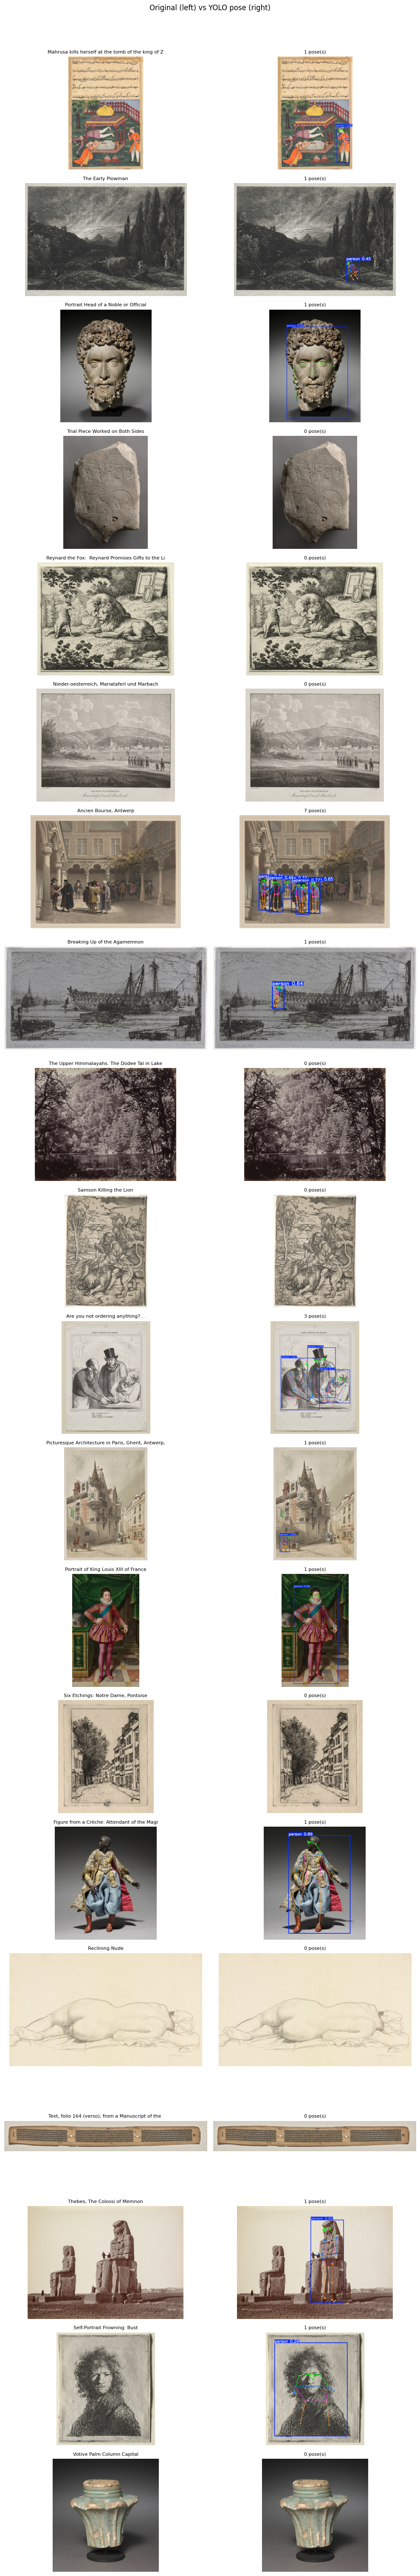

In [7]:
import matplotlib.pyplot as plt

N_SHOW = 20
fig, axes = plt.subplots(N_SHOW, 2, figsize=(10, 3 * N_SHOW))
fig.suptitle("Original (left) vs YOLO pose (right)", y=1.01)

for i in range(min(N_SHOW, len(pose_results))):
    orig_rgb = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
    pose_rgb = cv2.cvtColor(pose_results[i].plot(), cv2.COLOR_BGR2RGB)
    n_poses = len(pose_results[i].boxes)

    axes[i, 0].imshow(orig_rgb)
    axes[i, 0].set_title(str(meta[i]["title"])[:50], fontsize=8)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(pose_rgb)
    axes[i, 1].set_title(f"{n_poses} pose(s)", fontsize=8)
    axes[i, 1].axis("off")

if N_SHOW:
    axes[0, 0].set_ylabel("original", fontsize=9)
    axes[0, 1].set_ylabel("pose", fontsize=9)

plt.tight_layout()
plt.show()